In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
#Loading Cleaned Data
print("Loading cleaned data...")
df = pd.read_csv('cleaned_data_for_python.csv')
df['date'] = pd.to_datetime(df['date'])

Loading cleaned data...


In [3]:
#Defining platforms and currency pairs
platforms = ['paypal', 'wise', 'revolut']
currency_pairs = df['slug'].unique().tolist()

print(f"Currency pairs: {currency_pairs}")
print(f"Total observations: {len(df)}")

Currency pairs: ['EUR/USD', 'EUR/GBP', 'EUR/JPY']
Total observations: 3845


In [14]:
def run_regression(data, platform, currency):
    """
    Run OLS regression for a specific platform and currency pair.
    Dependent variable: final_cost
    Independent variables: close (exchange rate), markup, month (as categorical), day_of_week (as categorical)
    """
    # Create a copy to avoid modifying the original DataFrame
    data_copy = data.copy()

    # Convert relevant columns to numeric, coercing errors to NaN
    data_copy['close'] = pd.to_numeric(data_copy['close'], errors='coerce')
    data_copy[f'{platform}_markup'] = pd.to_numeric(data_copy[f'{platform}_markup'], errors='coerce')
    data_copy[f'{platform}_final_cost'] = pd.to_numeric(data_copy[f'{platform}_final_cost'], errors='coerce')

    # Filter data based on currency and ensure all relevant columns are not NaN
    relevant_cols_for_na = ['close', f'{platform}_markup', f'{platform}_final_cost']
    subset = data_copy[data_copy['slug'] == currency].dropna(subset=relevant_cols_for_na)

    if len(subset) < 30:
        print(f"Skipping {platform} - {currency}: insufficient observations ({len(subset)})")
        return None

    # Prepare features
    X = subset[['close', f'{platform}_markup']].copy()  # Use platform-specific markup columns

    # Add time dummies (month and day_of_week as categorical)
    # Ensure 'month' and 'day_of_week' are treated as categories, not just numbers
    X['month'] = subset['month'].astype('category')
    X['day_of_week'] = subset['day_of_week'].astype('category')

    # Convert categorical to dummies
    X = pd.get_dummies(X, columns=['month', 'day_of_week'], drop_first=True)

    # Add constant
    X = sm.add_constant(X)

    # Dependent variable: final_cost for this platform
    y = subset[f'{platform}_final_cost']

    # Ensure X and y are purely numeric (float) before passing to OLS
    # This addresses the "Pandas data cast to numpy dtype of object" error
    X_numeric = X.select_dtypes(include=[np.number]).astype(float)
    y_numeric = y.astype(float)

    # Fit model
    model = sm.OLS(y_numeric, X_numeric).fit()

    return model, subset

In [18]:
# Running Regressions
results = {}
all_coefficients = []

for platform in platforms:
    print(f"\n")
    print(f"Running regressions for {platform.upper()}")

    for currency in currency_pairs:
        print(f"\n {platform.upper()} | {currency} ")

        result = run_regression(df, platform, currency)
        if result is None:
            continue

        model, subset = result
        results[f'{platform}_{currency}'] = model

        #Save summary to text file
        with open(f'{platform}_{currency.replace("/","_")}_summary.txt', 'w') as f:
            f.write(f"REGRESSION SUMMARY: {platform.upper()} | {currency}\n")
            f.write(f"Observations: {len(subset)}\n")
            f.write(f"R-squared: {model.rsquared:.4f}\n")
            f.write(f"Adjusted R-squared: {model.rsquared_adj:.4f}\n")
            f.write(f"F-statistic: {model.fvalue:.2f} (p={model.f_pvalue:.4f})\n\n")
            f.write(model.summary().as_text())

        #Extract coefficients and p-values
        coef_df = model.params.to_frame(name='coefficient')
        coef_df['p_value'] = model.pvalues
        coef_df['platform'] = platform
        coef_df['currency'] = currency
        coef_df['variable'] = coef_df.index
        all_coefficients.append(coef_df.reset_index(drop=True))

        #Print key results
        print(f"  R² = {model.rsquared:.4f}")
        print(f"  Exchange rate coefficient (close): {model.params.get('close', 'N/A')}")
        print(f"  P-value for close: {model.pvalues.get('close', 'N/A')}")
        print(f"  Significant? {'YES (p<0.05)' if model.pvalues.get('close', 1) < 0.05 else 'NO'}")



Running regressions for PAYPAL

 PAYPAL | EUR/USD 
  R² = 1.0000
  Exchange rate coefficient (close): 1031.062044160262
  P-value for close: 0.0
  Significant? YES (p<0.05)

 PAYPAL | EUR/GBP 
  R² = 1.0000
  Exchange rate coefficient (close): 1031.0620441602623
  P-value for close: 0.0
  Significant? YES (p<0.05)

 PAYPAL | EUR/JPY 
  R² = 1.0000
  Exchange rate coefficient (close): 1031.062044160259
  P-value for close: 0.0
  Significant? YES (p<0.05)


Running regressions for WISE

 WISE | EUR/USD 
  R² = 1.0000
  Exchange rate coefficient (close): 1004.9999999999957
  P-value for close: 0.0
  Significant? YES (p<0.05)

 WISE | EUR/GBP 
  R² = 1.0000
  Exchange rate coefficient (close): 1004.999999999997
  P-value for close: 0.0
  Significant? YES (p<0.05)

 WISE | EUR/JPY 
  R² = 1.0000
  Exchange rate coefficient (close): 1005.0000000000016
  P-value for close: 0.0
  Significant? YES (p<0.05)


Running regressions for REVOLUT

 REVOLUT | EUR/USD 


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


  R² = 1.0000
  Exchange rate coefficient (close): 1000.0000000000011
  P-value for close: 0.0
  Significant? YES (p<0.05)

 REVOLUT | EUR/GBP 
  R² = 1.0000
  Exchange rate coefficient (close): 999.9999999999953
  P-value for close: 0.0
  Significant? YES (p<0.05)

 REVOLUT | EUR/JPY 
  R² = 1.0000
  Exchange rate coefficient (close): 1000.0000000000011
  P-value for close: 0.0
  Significant? YES (p<0.05)


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


In [19]:
#Extracting coefficients and p-values

print("\n")
print("Extracting coefficients and p-values")

coef_df_all = pd.concat(all_coefficients, ignore_index=True)
# Save to Excel
coef_df_all.to_excel('regression_coefficients.xlsx', index=False)



Extracting coefficients and p-values


In [20]:
#Hypothesis Testing
print("\n")
print("Hypothesis Testing (p < 0.05 for exchange rate coefficient)")

hypothesis_results = []
for key, model in results.items():
    platform, currency = key.split('_')
    p_val = model.pvalues.get('close', 1.0)
    coef = model.params.get('close', 0)
    significant = p_val < 0.05
    hypothesis_results.append({
        'Platform': platform,
        'Currency': currency,
        'Coefficient': coef,
        'P-value': p_val,
        'Significant (p<0.05)': significant,
        'Conclusion': 'Reject H0' if significant else 'Fail to reject H0'
    })

hypothesis_df = pd.DataFrame(hypothesis_results)
hypothesis_df.to_excel('hypothesis_test_results.xlsx', index=False)
print("\nHypothesis Test Summary:")
print(hypothesis_df.to_string(index=False))



Hypothesis Testing (p < 0.05 for exchange rate coefficient)

Hypothesis Test Summary:
Platform Currency  Coefficient  P-value  Significant (p<0.05) Conclusion
  paypal  EUR/USD  1031.062044      0.0                  True  Reject H0
  paypal  EUR/GBP  1031.062044      0.0                  True  Reject H0
  paypal  EUR/JPY  1031.062044      0.0                  True  Reject H0
    wise  EUR/USD  1005.000000      0.0                  True  Reject H0
    wise  EUR/GBP  1005.000000      0.0                  True  Reject H0
    wise  EUR/JPY  1005.000000      0.0                  True  Reject H0
 revolut  EUR/USD  1000.000000      0.0                  True  Reject H0
 revolut  EUR/GBP  1000.000000      0.0                  True  Reject H0
 revolut  EUR/JPY  1000.000000      0.0                  True  Reject H0




Creating diagnostic plots
Diagnostic plots saved


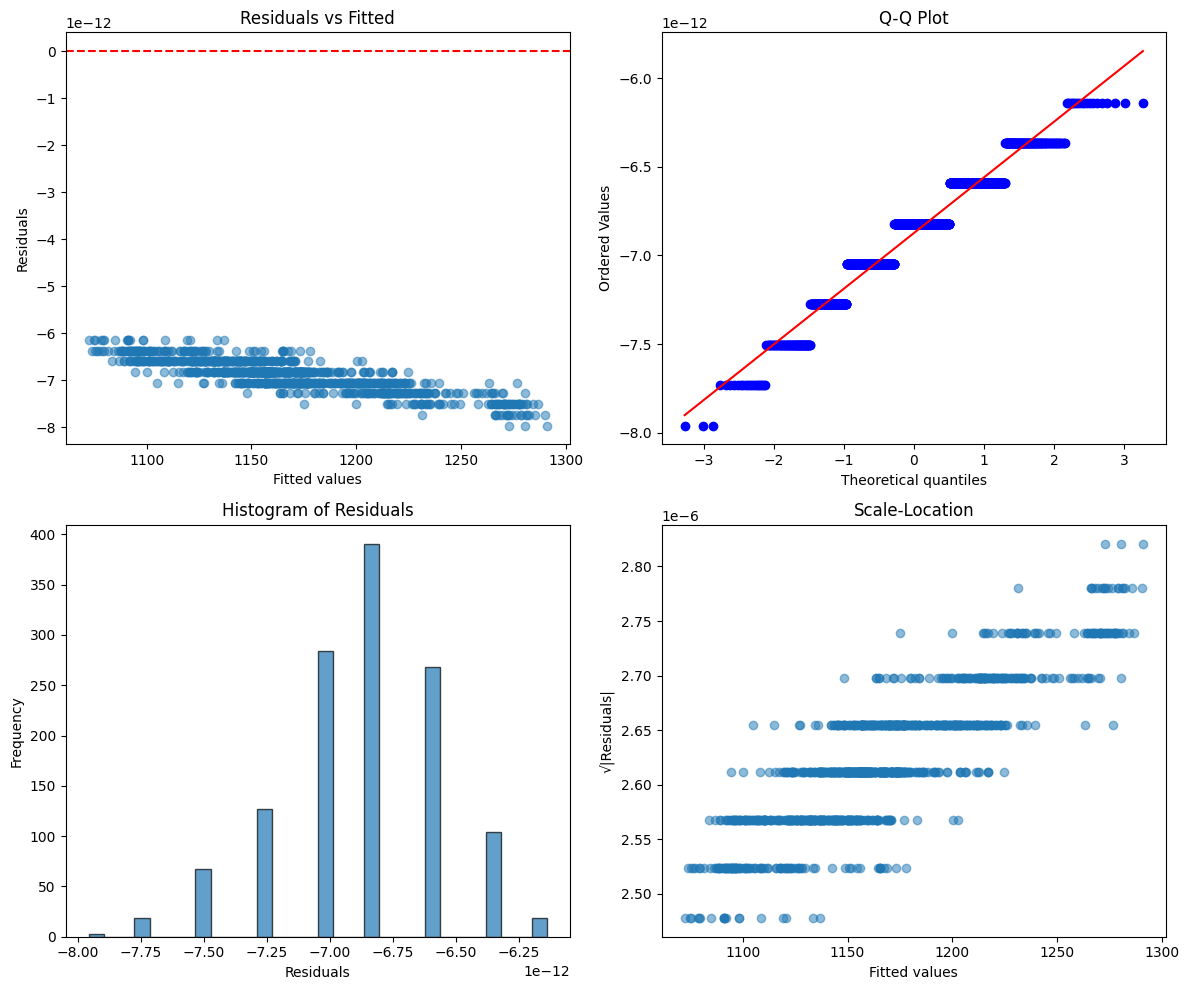

In [21]:
#Regression Diagnostic Plots
print("\n")
print("Creating diagnostic plots")

#Using Paypal model for demonstration
sample_model = results.get('paypal_EUR/USD')
if sample_model is not None:
    #Get residuals and fitted values
    residuals = sample_model.resid
    fitted = sample_model.fittedvalues

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    #Residuals vs Fitted
    axes[0, 0].scatter(fitted, residuals, alpha=0.5)
    axes[0, 0].axhline(y=0, color='r', linestyle='--')
    axes[0, 0].set_xlabel('Fitted values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Residuals vs Fitted')

    #Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot')

    #Histogram of residuals
    axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Residuals')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Histogram of Residuals')

    #Scale-Location plot
    axes[1, 1].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5)
    axes[1, 1].set_xlabel('Fitted values')
    axes[1, 1].set_ylabel('√|Residuals|')
    axes[1, 1].set_title('Scale-Location')

    plt.tight_layout()
    plt.savefig('regression_diagnostics.pdf')
    print("Diagnostic plots saved")
else:
    print("Skipping diagnostic plots - no sample model available")
